# GNN Top-k Analysis
Vergleich der Modell-Performance nach Feature-Selection-Methode und Visualisierung des Zusammenhangs zwischen selektierten Features und Test-Loss.

In [36]:
from pathlib import Path
import ast
import json
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection

# Visual style
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

METHOD_ORDER = [
    'GNNExplainer',
    'Integrated Gradients',
    'Ablation Study',
    'Random',
]

VIOLIN_METHOD_ORDER = [
    'GNNExplainer',
    'Integrated Gradients',
    'Ablation Study',
    'Full Feature Set',
]

METHOD_PALETTE = {
    'GNNExplainer': '#004e9f',
    'Integrated Gradients': '#fcba00',
    'Ablation Study': '#909085',
    'Random': '#6f6f64',
    'Full Feature Set': '#2f3e46',
}


In [37]:
SOURCE_DIR_CANDIDATES = {
    'gnn_topk': [
        Path('../results/gnn_topk'),
        Path('results/gnn_topk'),
        Path('gnn4nmr/results/gnn_topk'),
    ],
    'gnn_topk2': [
        Path('../results/gnn_topk2'),
        Path('results/gnn_topk2'),
        Path('gnn4nmr/results/gnn_topk2'),
    ],
    'gnn_topk3': [
        Path('../results/gnn_topk3'),
        Path('results/gnn_topk3'),
        Path('gnn4nmr/results/gnn_topk3'),
    ],
}


def resolve_existing_dir(candidates):
    return next((p for p in candidates if p.exists()), None)


def clean_colname(col):
    text = str(col).strip().strip('"').strip("'").strip()
    text = re.sub(r'\.\d+$', '', text)
    return text


def coalesce_duplicate_columns(df):
    normalized = [clean_colname(c) for c in df.columns]
    df = df.copy()
    df.columns = normalized

    merged = {}
    for col in dict.fromkeys(normalized):
        same_cols = df.loc[:, df.columns == col]
        if same_cols.shape[1] == 1:
            merged[col] = same_cols.iloc[:, 0]
        else:
            merged[col] = same_cols.bfill(axis=1).iloc[:, 0]
    return pd.DataFrame(merged)


def parse_feature_list(value):
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]

    text = str(value).strip()
    if not text or text.lower() in {'nan', 'none'}:
        return []

    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
        except Exception:
            pass

    text = re.sub(r'^\[|\]$', '', text)
    return [part.strip().strip('"').strip("'") for part in text.split(',') if part.strip()]


def load_single_file(path, source_group):
    raw = pd.read_csv(path, skipinitialspace=True)
    df = coalesce_duplicate_columns(raw).dropna(how='all')

    # Alias harmonization for run_results format.
    if 'run_name' in df.columns and 'Name' not in df.columns:
        df['Name'] = df['run_name']
    if 'status' in df.columns and 'State' not in df.columns:
        df['State'] = df['status']
    if 'selected_item_count' in df.columns and 'selected_items' not in df.columns:
        df['selected_items'] = df['selected_item_count']

    for col in ['method', 'target', 'Name', 'State', 'run_name', 'selected_item_keys']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.strip('"').str.strip("'").str.strip()

    numeric_cols = [
        'seed',
        'mad_H',
        'mad_C',
        'mad_primary',
        'test_score',
        'test_loss',
        'selected_items',
        'selected_item_count',
        'best_val_score',
        'test_mae_H',
        'test_mae_C',
        'test_mse_H',
        'test_mse_C',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['source_file'] = path.name
    df['source_group'] = source_group
    return df



PLOT_EXPORT_BASE = resolve_existing_dir(SOURCE_DIR_CANDIDATES['gnn_topk']) or Path('.')
PLOT_EXPORT_DIR = PLOT_EXPORT_BASE / 'plots'
PLOT_EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def export_pdf(fig, filename):
    out_path = PLOT_EXPORT_DIR / filename
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f'Plot exported: {out_path}')
    return out_path

loaded_frames = []
source_overview = []

for source_group, candidates in SOURCE_DIR_CANDIDATES.items():
    src_dir = resolve_existing_dir(candidates)
    if src_dir is None:
        source_overview.append({'source_group': source_group, 'directory': None, 'files': 0})
        continue

    csv_files = sorted(src_dir.glob('*.csv'))
    source_overview.append({'source_group': source_group, 'directory': str(src_dir), 'files': len(csv_files)})

    for csv_file in csv_files:
        loaded_frames.append(load_single_file(csv_file, source_group))

if not loaded_frames:
    raise FileNotFoundError('Keine CSV-Dateien in gnn_topk / gnn_topk2 gefunden.')

runs = pd.concat(loaded_frames, ignore_index=True)

if 'target' not in runs.columns or runs['target'].isna().all():
    if 'Name' in runs.columns:
        runs['target'] = runs['Name'].astype(str).str.extract(r'^([HC])_')

runs['target'] = runs['target'].astype(str).str.strip().str.upper()

runs['method_key'] = runs['method'].astype(str).str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
METHOD_LABELS = {
    'gnnexplainer': 'GNNExplainer',
    'integrated_gradients': 'Integrated Gradients',
    'ablation': 'Ablation Study',
    'random': 'Random',
}
runs['method_label'] = runs['method_key'].map(METHOD_LABELS).fillna(runs['method'])

# Keep only expected comparison methods.
runs = runs[runs['method_label'].isin(set(METHOD_ORDER))].copy()

if 'selected_item_keys' in runs.columns:
    runs['selected_features'] = runs['selected_item_keys'].apply(parse_feature_list)
else:
    runs['selected_features'] = [[] for _ in range(len(runs))]

selected_from_items = pd.to_numeric(runs['selected_items'], errors='coerce') if 'selected_items' in runs.columns else pd.Series(np.nan, index=runs.index)
selected_from_count = pd.to_numeric(runs['selected_item_count'], errors='coerce') if 'selected_item_count' in runs.columns else pd.Series(np.nan, index=runs.index)
runs['selected_item_count'] = selected_from_items.fillna(selected_from_count)

if 'test_score' not in runs.columns:
    runs['test_score'] = np.nan
if 'mad_primary' not in runs.columns:
    runs['mad_primary'] = np.nan

# Unified evaluation axis for joint visualization across both formats.
runs['test_loss'] = runs['test_score']
runs['test_loss'] = runs['test_loss'].fillna(runs['mad_primary'])
target_mad_fallback = pd.Series(
    np.where(runs['target'] == 'H', runs['mad_H'], runs['mad_C']),
    index=runs.index,
)
runs['test_loss'] = runs['test_loss'].fillna(target_mad_fallback)

runs['test_loss_source'] = np.where(
    runs['test_score'].notna(),
    'test_score',
    np.where(runs['mad_primary'].notna(), 'mad_primary', 'target_mad')
)


# Full-feature baseline (MAE) for violin plots.
full_feature_dir = resolve_existing_dir(SOURCE_DIR_CANDIDATES['gnn_topk3'])
full_feature_runs = pd.DataFrame(columns=['seed', 'target', 'mad_H', 'mad_C', 'method_label', 'source_group', 'source_file'])

if full_feature_dir is not None:
    full_feature_path = full_feature_dir / 'seed_test_results_graphconv.csv'
    if full_feature_path.exists():
        ff = pd.read_csv(full_feature_path)
        ff.columns = [clean_colname(c) for c in ff.columns]
        ff['seed'] = pd.to_numeric(ff.get('seed'), errors='coerce')
        ff['test_mae_H'] = pd.to_numeric(ff.get('test_mae_H'), errors='coerce')
        ff['test_mae_C'] = pd.to_numeric(ff.get('test_mae_C'), errors='coerce')

        ff_h = pd.DataFrame({
            'seed': ff['seed'],
            'target': 'H',
            'mad_H': ff['test_mae_H'],
            'mad_C': np.nan,
            'method_label': 'Full Feature Set',
            'source_group': 'gnn_topk3',
            'source_file': full_feature_path.name,
        })

        ff_c = pd.DataFrame({
            'seed': ff['seed'],
            'target': 'C',
            'mad_H': np.nan,
            'mad_C': ff['test_mae_C'],
            'method_label': 'Full Feature Set',
            'source_group': 'gnn_topk3',
            'source_file': full_feature_path.name,
        })

        full_feature_runs = pd.concat([ff_h, ff_c], ignore_index=True)

# Violin plot input: remove Random and add Full Feature Set baseline.
runs_violin = runs[runs['method_label'] != 'Random'].copy()
if not full_feature_runs.empty:
    runs_violin = pd.concat([runs_violin, full_feature_runs], ignore_index=True, sort=False)

print('Quellen:')
display(pd.DataFrame(source_overview))
print(f'Runs gesamt (gefiltert auf Methoden): {len(runs)}')
print('Runs pro Quelle:')
display(runs.groupby('source_group').size().rename('n_runs').reset_index())
display(runs[['source_group', 'source_file', 'method_label', 'seed', 'target', 'mad_H', 'mad_C', 'test_loss']].head())
print(f'Violin input runs (without Random + Full Feature Set): {len(runs_violin)}')
if not full_feature_runs.empty:
    print(f'Full Feature Set rows added: {len(full_feature_runs)}')


Quellen:


,source_group,directory,files
0,gnn_topk,..\results\gnn_topk,43
1,gnn_topk2,..\results\gnn_topk2,1
2,gnn_topk3,..\results\gnn_topk3,1


Runs gesamt (gefiltert auf Methoden): 82
Runs pro Quelle:


,source_group,n_runs
0,gnn_topk,78
1,gnn_topk2,4


,source_group,source_file,method_label,seed,target,mad_H,mad_C,test_loss
74,gnn_topk,wandb_export_2026-03-09T22_50_32.450+01_00.csv,GNNExplainer,0.0,C,0.035316,0.638746,0.504650
75,gnn_topk,wandb_export_2026-03-09T22_50_32.450+01_00.csv,GNNExplainer,0.0,H,0.040296,0.623569,0.522786
76,gnn_topk,wandb_export_2026-03-09T22_50_45.823+01_00.csv,Integrated Gradients,0.0,C,0.035035,0.651752,0.508005
77,gnn_topk,wandb_export_2026-03-09T22_50_45.823+01_00.csv,Integrated Gradients,0.0,H,0.036120,0.710221,0.543965
78,gnn_topk,wandb_export_2026-03-09T22_50_51.087+01_00.csv,Ablation Study,0.0,C,0.038560,0.724020,0.569815


Violin input runs (without Random + Full Feature Set): 264
Full Feature Set rows added: 202


In [38]:
summary = (
    runs.groupby(['source_group', 'method_label', 'target'], dropna=False)
    .agg(
        n_runs=('source_file', 'size'),
        mad_H_mean=('mad_H', 'mean'),
        mad_C_mean=('mad_C', 'mean'),
        test_loss_mean=('test_loss', 'mean'),
    )
    .reset_index()
)

display(summary.sort_values(['source_group', 'target', 'method_label']))


,source_group,method_label,target,n_runs,mad_H_mean,mad_C_mean,test_loss_mean
0,gnn_topk,Ablation Study,C,10,0.039506,0.717940,0.558368
2,gnn_topk,GNNExplainer,C,10,0.038336,0.766092,0.570540
4,gnn_topk,Integrated Gradients,C,10,0.037492,0.727638,0.550574
6,gnn_topk,Random,C,9,0.037566,0.812762,0.584873
1,gnn_topk,Ablation Study,H,10,0.037750,0.698209,0.536250
3,gnn_topk,GNNExplainer,H,10,0.041156,0.704167,0.557037
5,gnn_topk,Integrated Gradients,H,10,0.038006,0.750609,0.562154
7,gnn_topk,Random,H,9,0.038686,0.846710,0.606760
8,gnn_topk2,Ablation Study,C,1,0.044298,0.793143,0.793143
10,gnn_topk2,Random,C,1,0.039834,0.778852,0.778852


Plot exported: ..\results\gnn_topk\plots\mad_violin_h_predictions.pdf


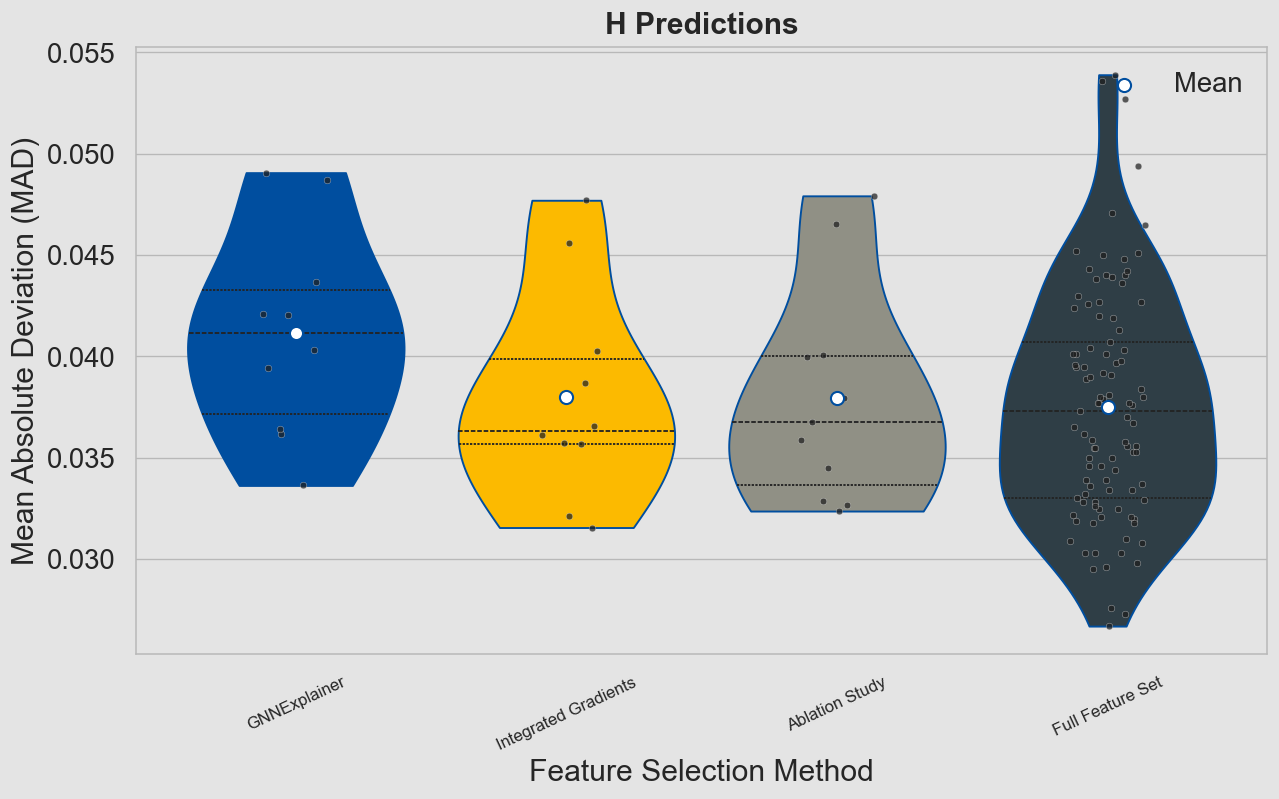

Plot exported: ..\results\gnn_topk\plots\mad_violin_c_predictions.pdf


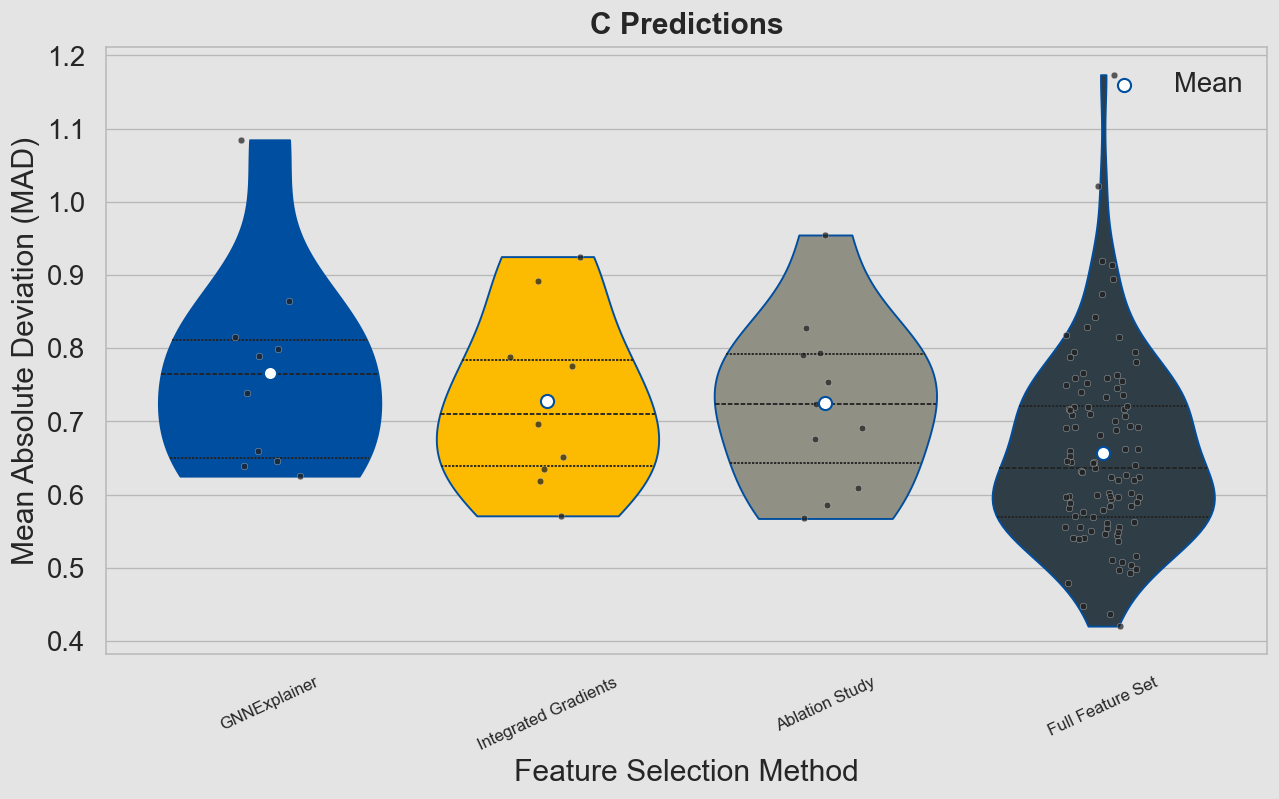

In [39]:
def method_palette_for_violin(data):
    present = data['method_label'].dropna().unique().tolist()
    ordered = [m for m in VIOLIN_METHOD_ORDER if m in present] + [m for m in present if m not in VIOLIN_METHOD_ORDER]
    palette = {m: METHOD_PALETTE.get(m, '#909085') for m in ordered}
    return ordered, palette


def style_violin_axis(ax):
    ax.set_facecolor('#e4e4e4')
    ax.figure.set_facecolor('#e4e4e4')
    ax.grid(axis='y', color='#b8b8b8', linewidth=0.8)
    ax.grid(axis='x', visible=False)
    for spine in ax.spines.values():
        spine.set_color('#b8b8b8')
        spine.set_linewidth(0.9)


def plot_mad_violin(data, target, metric):
    plot_df = data.loc[
        (data['target'].astype(str).str.upper() == target) & data[metric].notna(),
        ['method_label', metric, 'seed']
    ].copy()

    method_order, palette = method_palette_for_violin(plot_df)

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.violinplot(
        data=plot_df,
        x='method_label',
        y=metric,
        hue='method_label',
        order=method_order,
        hue_order=method_order,
        palette=palette,
        inner='quartile',
        cut=0,
        density_norm='width',
        linewidth=1.1,
        saturation=1,
        dodge=False,
        legend=False,
        ax=ax,
    )

    for coll in ax.findobj(PolyCollection):
        coll.set_edgecolor('#004e9f')
        coll.set_linewidth(1.15)

    sns.stripplot(
        data=plot_df,
        x='method_label',
        y=metric,
        order=method_order,
        color='#1f1f1f',
        size=4.0,
        alpha=0.72,
        jitter=0.14,
        linewidth=0.25,
        edgecolor='#f2f2f2',
        ax=ax,
    )

    means = plot_df.groupby('method_label')[metric].mean().reindex(method_order)
    ax.scatter(
        np.arange(len(method_order)),
        means.values,
        marker='o',
        s=62,
        facecolor='white',
        edgecolor='#004e9f',
        linewidth=1.25,
        zorder=6,
        label='Mean',
    )

    style_violin_axis(ax)
    ax.set_title(f'{target} Predictions', weight='bold', pad=8)
    ax.set_xlabel('Feature Selection Method')
    ax.set_ylabel('Mean Absolute Deviation (MAD)')
    ax.tick_params(axis='x', rotation=25, labelsize=10)
    ax.legend(loc='upper right', frameon=False)

    export_pdf(fig, f'mad_violin_{target.lower()}_predictions.pdf')
    plt.tight_layout()
    plt.show()


plot_mad_violin(
    runs_violin,
    target='H',
    metric='mad_H',
)

plot_mad_violin(
    runs_violin,
    target='C',
    metric='mad_C',
)


Plot exported: ..\results\gnn_topk\plots\selected_features_vs_test_loss.pdf


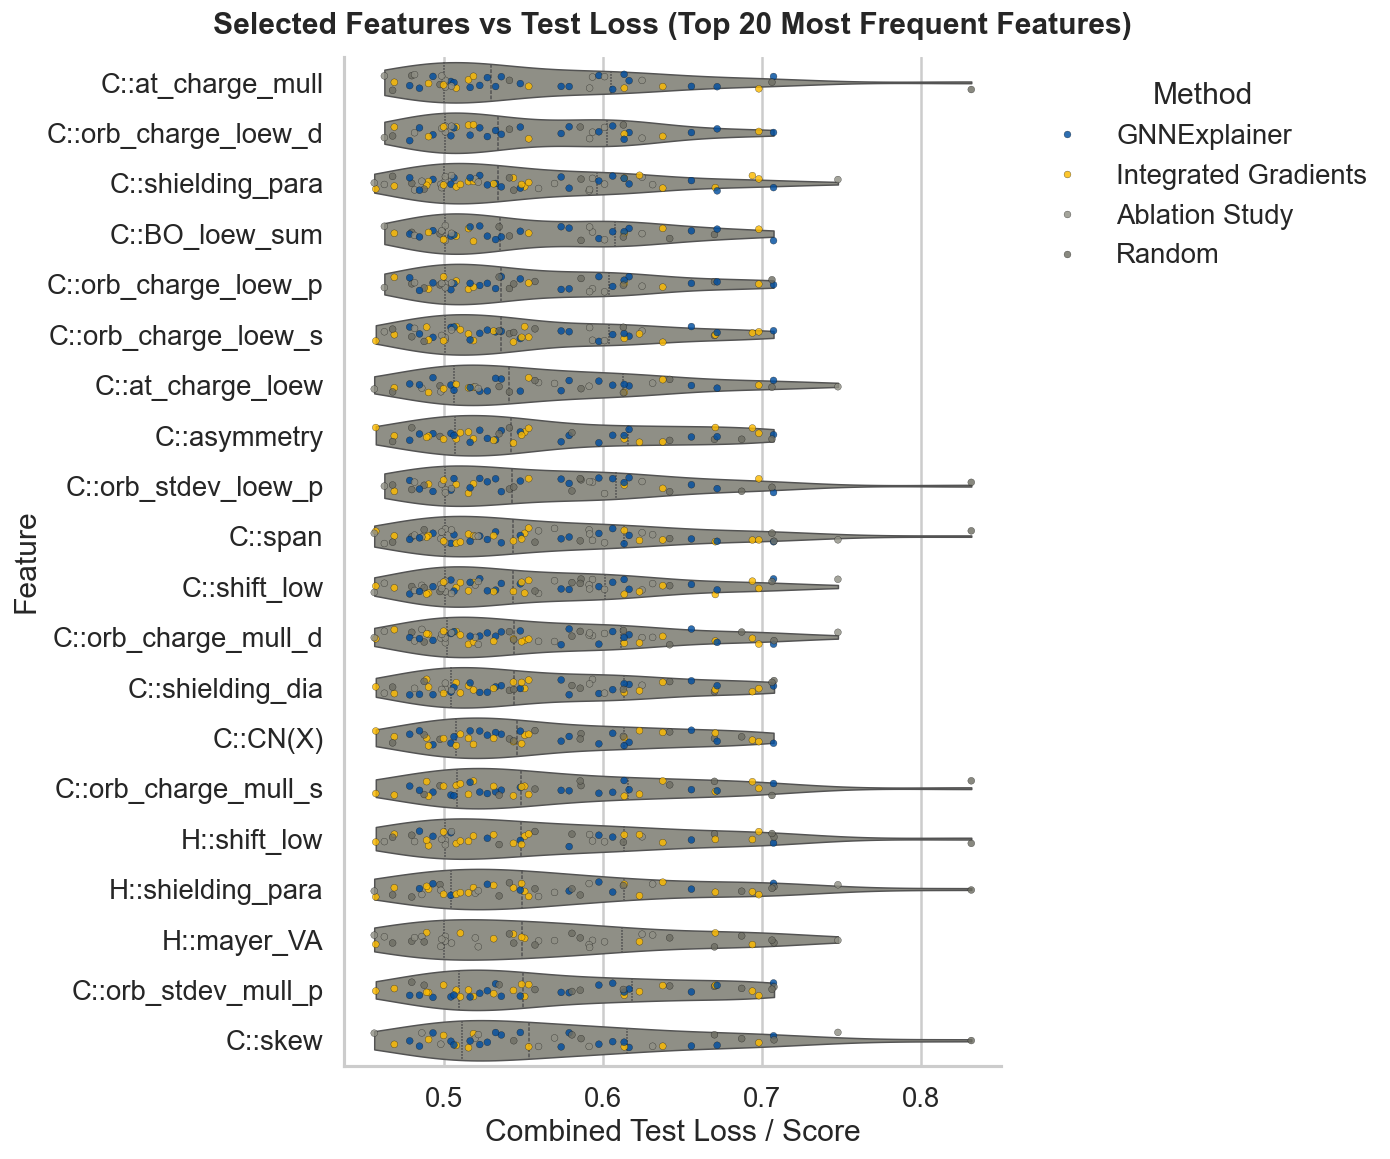

In [40]:
feature_long = runs[['source_group', 'method_label', 'target', 'test_loss', 'selected_features']].explode('selected_features')
feature_long = feature_long.rename(columns={'selected_features': 'feature'})
feature_long['feature'] = feature_long['feature'].astype(str).str.strip()
feature_long = feature_long[(feature_long['feature'] != '') & (feature_long['feature'].str.lower() != 'nan')]
feature_long = feature_long.dropna(subset=['test_loss'])

if feature_long.empty:
    print('No feature-level data available (selected_item_keys missing).')
else:
    top_features = feature_long['feature'].value_counts().head(20).index.tolist()
    feature_plot_df = feature_long[feature_long['feature'].isin(top_features)].copy()

    feature_order = (
        feature_plot_df.groupby('feature')['test_loss']
        .median()
        .sort_values()
        .index
    )

    feature_method_order = [m for m in METHOD_ORDER if m in feature_plot_df['method_label'].unique()]
    feature_palette = {m: METHOD_PALETTE.get(m, '#909085') for m in feature_method_order}

    fig, ax = plt.subplots(figsize=(12, 10))

    sns.violinplot(
        data=feature_plot_df,
        x='test_loss',
        y='feature',
        order=feature_order,
        color='#909085',
        inner='quartile',
        linewidth=0.9,
        cut=0,
        density_norm='width',
        ax=ax,
    )

    sns.stripplot(
        data=feature_plot_df,
        x='test_loss',
        y='feature',
        order=feature_order,
        hue='method_label',
        hue_order=feature_method_order,
        palette=feature_palette,
        size=4.1,
        alpha=0.82,
        jitter=0.16,
        dodge=False,
        linewidth=0.2,
        edgecolor='#101010',
        ax=ax,
    )

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    clean_handles, clean_labels = [], []
    for handle, label in zip(handles, labels):
        if label not in seen:
            seen.add(label)
            clean_handles.append(handle)
            clean_labels.append(label)

    ax.legend(clean_handles, clean_labels, title='Method', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    ax.set_title('Selected Features vs Test Loss (Top 20 Most Frequent Features)', pad=14, weight='bold')
    ax.set_xlabel('Combined Test Loss / Score')
    ax.set_ylabel('Feature')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    export_pdf(fig, 'selected_features_vs_test_loss.pdf')
    plt.tight_layout()
    plt.show()


Plot exported: ..\results\gnn_topk\plots\selected_feature_count_vs_test_loss.pdf


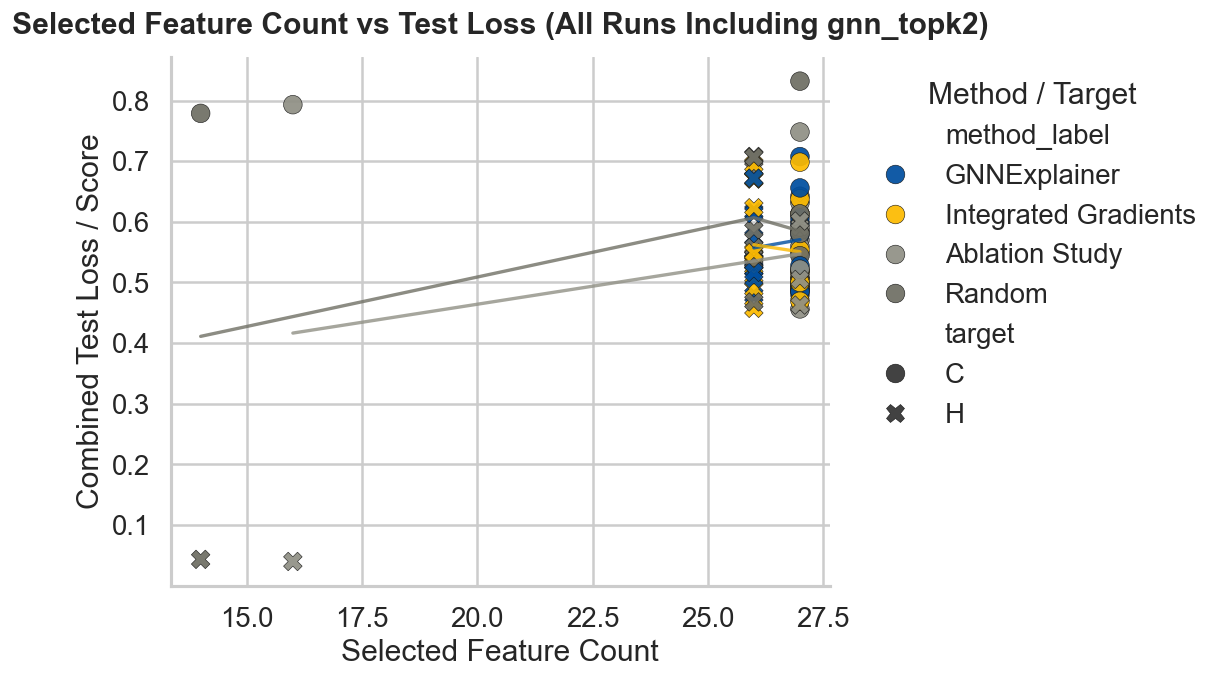

In [41]:
count_df = runs.dropna(subset=['selected_item_count', 'test_loss']).copy()

if count_df.empty:
    print('No data available for selected_item_count vs test_loss.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.scatterplot(
        data=count_df,
        x='selected_item_count',
        y='test_loss',
        hue='method_label',
        hue_order=[m for m in METHOD_ORDER if m in count_df['method_label'].unique()],
        style='target',
        palette=METHOD_PALETTE,
        s=125,
        alpha=0.93,
        edgecolor='#111111',
        linewidth=0.35,
        ax=ax,
    )

    trend_df = (
        count_df.assign(selected_item_count=count_df['selected_item_count'].round().astype(int))
        .groupby(['method_label', 'selected_item_count'], as_index=False)['test_loss']
        .mean()
    )

    sns.lineplot(
        data=trend_df,
        x='selected_item_count',
        y='test_loss',
        hue='method_label',
        hue_order=[m for m in METHOD_ORDER if m in trend_df['method_label'].unique()],
        palette=METHOD_PALETTE,
        legend=False,
        linewidth=2.0,
        alpha=0.8,
        ax=ax,
    )

    ax.set_title('Selected Feature Count vs Test Loss (All Runs Including gnn_topk2)', pad=14, weight='bold')
    ax.set_xlabel('Selected Feature Count')
    ax.set_ylabel('Combined Test Loss / Score')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.legend(title='Method / Target', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    export_pdf(fig, 'selected_feature_count_vs_test_loss.pdf')
    plt.tight_layout()
    plt.show()


In [42]:
if feature_long.empty:
    print('Feature-Statistik nicht verfuegbar (keine selected_item_keys).')
else:
    feature_stats = (
        feature_long.groupby('feature')
        .agg(
            selections=('feature', 'size'),
            mean_test_loss=('test_loss', 'mean'),
            median_test_loss=('test_loss', 'median'),
        )
        .sort_values('mean_test_loss')
    )

    total_selections = feature_stats['selections'].sum()
    feature_stats['#selections relative'] = feature_stats['selections'] / total_selections

    feature_stats_export = feature_stats.reset_index()

    export_dir = resolve_existing_dir(SOURCE_DIR_CANDIDATES['gnn_topk']) or Path('.')
    export_path = export_dir / 'feature_stats_with_relative.csv'
    feature_stats_export.to_csv(export_path, index=False)

    print(f'Feature-Tabelle exportiert: {export_path}')
    display(feature_stats_export.head(20))


Feature-Tabelle exportiert: ..\results\gnn_topk\feature_stats_with_relative.csv


,feature,selections,mean_test_loss,median_test_loss,#selections relative
0,H::degree,14,0.536855,0.523243,0.006740
1,H::formal_charge,12,0.550444,0.519998,0.005778
2,Others::element_P,14,0.551341,0.533007,0.006740
3,C::shielding_para,66,0.552382,0.534566,0.031777
4,C::orb_charge_loew_d,44,0.553467,0.534566,0.021184
5,C::orb_charge_loew_s,59,0.553611,0.536366,0.028406
6,C::element_H,14,0.555352,0.545767,0.006740
7,C::orb_charge_loew_p,51,0.556164,0.536366,0.024555
8,H::orb_charge_loew_p,42,0.556210,0.546547,0.020221
9,C::BO_loew_sum,48,0.556470,0.535670,0.023110


In [43]:
# Method statistics exported separately for H and C.
stats_export_base = resolve_existing_dir(SOURCE_DIR_CANDIDATES['gnn_topk']) or Path('.')

TARGET_TO_METRIC = {
    'H': 'mad_H',
    'C': 'mad_C',
}

for target, metric in TARGET_TO_METRIC.items():
    stats_df = runs_violin.loc[
        (runs_violin['target'] == target) & runs_violin[metric].notna(),
        ['method_label', metric]
    ].copy()

    summary = (
        stats_df.groupby('method_label')[metric]
        .agg(['min', 'max', 'mean', 'median', 'std'])
        .rename(columns={
            'min': 'Min',
            'max': 'Max',
            'mean': 'Mittelwert',
            'median': 'Median',
            'std': 'Std',
        })
        .reset_index()
        .rename(columns={'method_label': 'Modell'})
    )

    summary['Modell'] = pd.Categorical(summary['Modell'], categories=VIOLIN_METHOD_ORDER, ordered=True)
    summary = summary.sort_values('Modell').reset_index(drop=True)

    for col in ['Min', 'Max', 'Mittelwert', 'Median', 'Std']:
        summary[col] = summary[col].round(6)

    out_path = stats_export_base / f'method_stats_{target.lower()}.csv'
    summary.to_csv(out_path, index=False)
    print(f'{target} stats exported: {out_path}')
    display(summary)


H stats exported: ..\results\gnn_topk\method_stats_h.csv


,Modell,Min,Max,Mittelwert,Median,Std
0,GNNExplainer,0.033638,0.049070,0.041156,0.041176,0.005105
1,Integrated Gradients,0.031562,0.047706,0.038006,0.036341,0.005267
2,Ablation Study,0.032375,0.047925,0.037954,0.036748,0.005336
3,Full Feature Set,0.026700,0.053900,0.037509,0.037300,0.005663


C stats exported: ..\results\gnn_topk\method_stats_c.csv


,Modell,Min,Max,Mittelwert,Median,Std
0,GNNExplainer,0.625149,1.084675,0.766092,0.764079,0.140589
1,Integrated Gradients,0.570920,0.925066,0.727638,0.710720,0.117180
2,Ablation Study,0.567314,0.954613,0.724776,0.724020,0.115807
3,Full Feature Set,0.420300,1.173600,0.656132,0.636400,0.124928
